In [1]:
#Import Libs
from matplotlib import pyplot as plot
import matplotlib as mpl
import urllib.request
import urllib.parse
import numpy as np
import math
import cv2

In [2]:
#URL Image
image_url = 'https://raw.githubusercontent.com/jrafa1607/Computational-Vision-In-Python/main/-%20Images/lenna.jpg'

In [3]:
#Open the Image
with urllib.request.urlopen(image_url) as url:
    s = url.read()

In [4]:
#Convert to a Numpy Array and Decode with cv2
img = cv2.imdecode(np.frombuffer(s, np.uint8), -1)

In [5]:
#Convert from BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

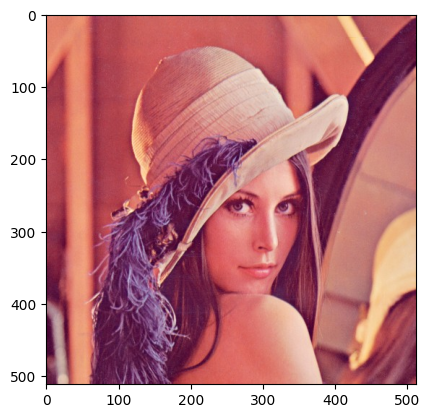

In [6]:
#Show the Image
plot.imshow(img,cmap='gray')
plot.show()

### High-Pass Filter (HPF)

A **High-Pass Filter** is used to emphasize fine details and sharpen an image.

*   **How it works**: It allows high-frequency signals (areas with rapid intensity changes, like **edges**) to pass through while reducing low-frequency signals (smooth areas with constant or slowly changing colors).
*   **The Kernel**: It typically uses a matrix where the center value is positive and the surrounding values are negative. This calculates the difference between a pixel and its neighbors.
*   **Result**: Smooth regions become dark (close to zero), and edges become bright, highlighting the boundaries within the image.

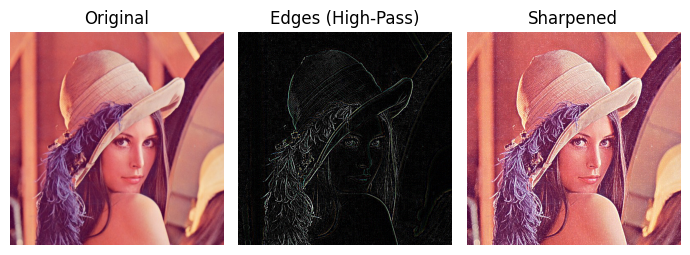

In [7]:
#High-Pass Filter
matriz = np.ones((3,3),np.float32)*-1
matriz[1][1] = 8

#Apply filter for edge detection
output = cv2.filter2D(img, -1, matriz)

#Sum original + edges for sharpening
output2 = cv2.add(img, output)

# Set up the visualization
titles = ['Original', 'Edges (High-Pass)', 'Sharpened']
images = [img, output, output2]

plot.figure(figsize=(7, 7))

for i in range(3):
    plot.subplot(1, 3, i+1)
    plot.imshow(images[i])
    plot.title(titles[i])
    plot.axis('off')

plot.tight_layout()
plot.show()

### Smoothing Filters (Low-Pass)

Unlike high-pass filters, smoothing filters are used to reduce noise and irrelevant details by 'blurring' the image. Here are the main ones:

1. **Mean Filter:**
   - **How it works:** It calculates the arithmetic mean of all pixels within the window (kernel) and replaces the central pixel with this value.
   - **Use case:** Uniform noise reduction, though it can blur important edges.

2. **Median Filter:**
   - **How it works:** It replaces the central pixel with the *median* value of the neighboring pixels.
   - **Use case:** Extremely effective against **'salt and pepper'** noise (random white and black dots), as it preserves edges better than the mean filter.

3. **Gaussian Filter:**
   - **How it works:** It uses a Gaussian function to calculate the weights of neighboring pixels. Pixels closer to the center have more influence than distant pixels.
   - **Use case:** The standard for natural smoothing and removing high-frequency noise; it serves as the foundation for many complex algorithms.

4. **Bilateral Filter:**
   - **How it works:** It considers both the spatial distance and the intensity (color) difference between pixels.
   - **Use case:** Highly efficient at reducing noise while **keeping edges sharp**, unlike other filters that tend to blur everything uniformly.

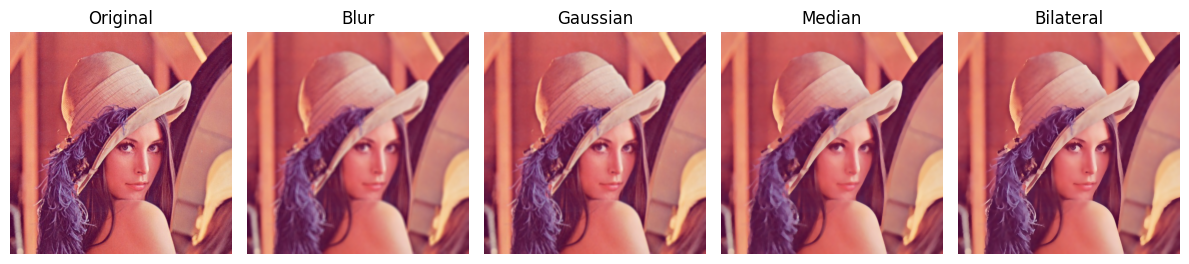

In [8]:
#Blur (Mean Filter)
img_blur = cv2.blur(img, (7, 7))

#Gaussian Blur
img_gaussian = cv2.GaussianBlur(img, (7, 7), 0)

#Median Blur
img_median = cv2.medianBlur(img, 7)

#Bilateral Filter
img_bilateral = cv2.bilateralFilter(img, 9, 75, 75)

# Set up the visualization
titles = ['Original', 'Blur', 'Gaussian', 'Median', 'Bilateral']
images = [img, img_blur, img_gaussian, img_median, img_bilateral]

plot.figure(figsize=(12, 12))

for i in range(5):
    plot.subplot(1, 5, i+1)
    plot.imshow(images[i])
    plot.title(titles[i])
    plot.axis('off')

plot.tight_layout()
plot.show()

### Filters for Intensity Transformations

In addition to spatial filters, we can transform an image pixel-by-pixel to improve contrast or invert colors:

#### 1. Negative Transformation
- **What it is:** Inverts the intensity values of the image. In an 8-bit image (0-255), each pixel value $r$ is transformed into $s = 255 - r$.
- **Use case:** Useful for enhancing white or grey details embedded in dark regions, commonly seen in medical imaging (like X-rays).

#### 2. Power-Law Transformation (Gamma Correction)
- **What it is:** Follows the formula $s = c \cdot r^\gamma$, where $c$ is a constant and $\gamma$ (gamma) is the power value.
- **How it works:**
    - If **$\gamma < 1$**: Expands the low gray levels (dark areas), making the image brighter and revealing details in shadows.
    - If **$\gamma > 1$**: Compresses the low gray levels and expands the high ones, making the image darker and increasing contrast in bright areas.
- **Use case:** Correcting brightness in monitors and enhancing details in underexposed or overexposed images.

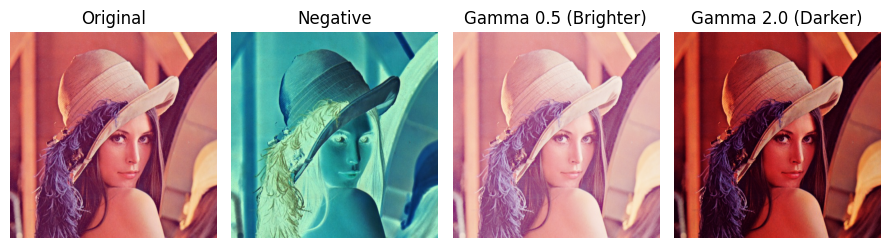

In [9]:
#Negative Transformation
img_negative = 255 - img

#Power-Law (Gamma) Transformation
def apply_gamma(image, gamma):
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** gamma) * 255
                      for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(image, table)

img_gamma_low = apply_gamma(img, 0.5)  # Brighter
img_gamma_high = apply_gamma(img, 2.0) # Darker

# Set up the visualization
titles = ['Original', 'Negative', 'Gamma 0.5 (Brighter)', 'Gamma 2.0 (Darker)']
images = [img, img_negative, img_gamma_low, img_gamma_high]

plot.figure(figsize=(9, 9))

for i in range(4):
    plot.subplot(1, 4, i+1)
    plot.imshow(images[i])
    plot.title(titles[i])
    plot.axis('off')

plot.tight_layout()
plot.show()

### Filters for Intensity Transformations ( Grayscale )

In [10]:
#Convert the Image from BGR to Grayscale
img_gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [11]:
#Find the gray value Max
print(img_gray.max())

231


In [12]:
#Image Normalization
e = img_gray/img_gray.max()

#### Image Normalization

In this step, we perform **Normalization** to scale the pixel values:

*   **The Operation**: `e = img_gray / img_gray.max()`
*   **Why we do it**: It converts the pixel range from **0-255** to **0.0-1.0**.
*   **Mathematical Purpose**: Mathematical transformations like the Power-Law (Gamma) are designed to work on decimals between 0 and 1. This prevents numerical overflow and ensures that the brightening/darkening logic remains consistent with standard image processing theory.

In [13]:
#Define a Gamma Value
gamma = 6.5

#### Gamma Correction Behavior

The effect of the **Gamma ($\gamma$)** value depends on whether the image is normalized or in its raw integer format:

1.  **Normalized Image (Range [0, 1]):**
    - **$\gamma < 1$**: The image becomes **Brighter**.
    - **$\gamma > 1$**: The image becomes **Darker**.

2.  **Standard Image (Range [0, 255]):**
    - Note that applying power functions directly to values above 1 (like 255) results in massive numbers. In typical libraries like OpenCV (using Look-Up Tables):
    - **$\gamma < 1$**: The image becomes **Darker**.
    - **$\gamma > 1$**: The image becomes **Brighter**.

*Always ensure you know if your code divides by 255 before applying the power law to avoid unexpected results!*

In [14]:
#Compute the Output ( Gamma Aplication )
output3 = e ** gamma * 255

In [15]:
#Compute the Output ( Negative Aplication )
output4 = e.max()-e

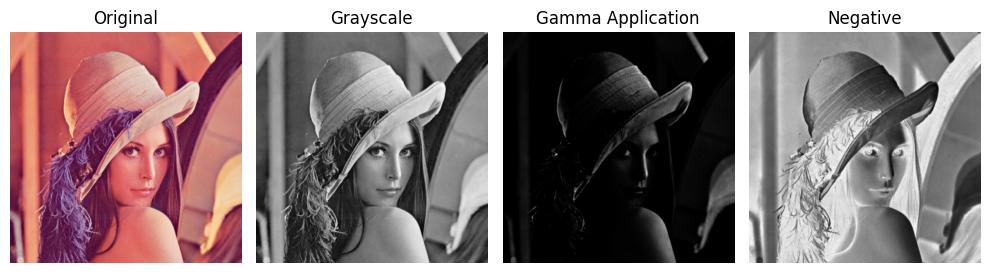

In [16]:
# Final Comparison Grid: Intensity Transformations on Grayscale
titles = ['Original', 'Grayscale', 'Gamma Application', 'Negative']
images = [img, img_gray, output3, output4]

plot.figure(figsize=(10, 10))

for i in range(4):
    plot.subplot(1, 4, i+1)
    # We use cmap='gray' for grayscale images (index 1, 2, 3)
    if i == 0:
        plot.imshow(images[i])
    else:
        plot.imshow(images[i], cmap='gray')
    plot.title(titles[i])
    plot.axis('off')

plot.tight_layout()
plot.show()